# 03 - Treino CNN1D (PyTorch)

Optuna focado na vizinhança da configuração final, usando desde cada trial o protocolo final do ensemble.
Cada trial treina em `dataset_combined + dataset-exemplos`, faz early stopping em `subm1` e avalia em `subm2`.


In [1]:
import sys
import os
import pickle
import random
import time
import json

os.environ.setdefault('ROCM_DISABLE_FLUSH_DENORM', '1')
os.environ.setdefault('HIP_VISIBLE_DEVICES', '0')
os.environ.setdefault('TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL', '0')

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

from src.data_processing import clean_text_sequences
from src.features import TextDataset, Vocabulary, load_glove_embeddings, texts_to_sequences
from src.hyperopt import create_study, study_results_dataframe, suggest_params
from src.models_pytorch.cnn1d import CNN1DClassifier
from src.stylometric_features import StylometricFeaturesExtractor


In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
N_TRIALS = 12

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'HIP_VISIBLE_DEVICES: {os.environ.get("HIP_VISIBLE_DEVICES")}')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU count: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')


HIP_VISIBLE_DEVICES: 0
Device: cuda
  GPU count: 1
  GPU 0: AMD Radeon Graphics


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


## 1. Dados


In [3]:
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
EXEMPLOS_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
EARLY_STOP_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')
EVAL_PATH = os.path.join(ROOT, 'data', 'validation', 'subm2_labels_revealed.csv')
GLOVE_PATH = os.path.join(ROOT, 'data', 'embeddings', 'glove.6B.100d.txt')
SAVED_MODELS_DIR = os.path.join(ROOT, 'saved_models')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    return df


df_train = load_data(TRAIN_PATH)
df_exemplos = load_data(EXEMPLOS_PATH)
df_full = pd.concat([df_train, df_exemplos], ignore_index=True)
df_es = load_data(EARLY_STOP_PATH)
df_eval = load_data(EVAL_PATH)

print(f'Train final: {len(df_full)} (combined={len(df_train)} + exemplos={len(df_exemplos)})')
print(f'Early stop (subm1): {len(df_es)}')
print(f'Eval (subm2): {len(df_eval)}')


Train final: 4740 (combined=4615 + exemplos=125)
Early stop (subm1): 100
Eval (subm2): 100


## 2. Espaço de Busca


In [4]:
search_space = {
    'vocab_size': [1000, 1500],
    'embedding_dim': [100],
    'n_filters': [64, 96],
    'filter_sizes': [(2, 3), (2, 3, 4)],
    'dropout': [0.2, 0.3],
    'lr': [0.0005, 0.001],
    'batch_size': [32],
    'max_len': [200],
    'epochs': [20, 30],
    'patience': [8],
}

for k, v in search_space.items():
    print(f'{k}: {v}')


vocab_size: [1000, 1500]
embedding_dim: [100]
n_filters: [64, 96]
filter_sizes: [(2, 3), (2, 3, 4)]
dropout: [0.2, 0.3]
lr: [0.0005, 0.001]
batch_size: [32]
max_len: [200]
epochs: [20, 30]
patience: [8]


## 3. Funções


In [5]:
def evaluate_probs(probs, labels, name):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}')
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.tight_layout()
    plt.show()
    return acc, macro_f1, preds


def train_cnn_trial(params, texts_tr, y_tr, texts_es, y_es):
    texts_tr_clean = [clean_text_sequences(text) for text in texts_tr]
    texts_es_clean = [clean_text_sequences(text) for text in texts_es]

    vocab = Vocabulary(max_words=params['vocab_size'])
    vocab.fit(texts_tr_clean)

    X_tr = texts_to_sequences(texts_tr_clean, vocab, max_len=params['max_len'])
    X_es = texts_to_sequences(texts_es_clean, vocab, max_len=params['max_len'])

    glove = load_glove_embeddings(GLOVE_PATH, vocab, embedding_dim=params['embedding_dim']) if os.path.exists(GLOVE_PATH) else None

    style_extractor = StylometricFeaturesExtractor()
    style_tr = style_extractor.fit_transform(texts_tr)
    style_es = style_extractor.transform(texts_es)
    style_eval = style_extractor.transform(df_eval['Text'].tolist())

    style_mean = style_tr.mean(axis=0)
    style_std = style_tr.std(axis=0) + 1e-8
    style_tr = (style_tr - style_mean) / style_std
    style_es = (style_es - style_mean) / style_std
    style_eval = (style_eval - style_mean) / style_std

    train_dl = DataLoader(TextDataset(X_tr, y_tr.astype(np.int64), style_tr), batch_size=params['batch_size'], shuffle=True)
    es_dl = DataLoader(TextDataset(X_es, y_es.astype(np.int64), style_es), batch_size=params['batch_size'])

    model = CNN1DClassifier(
        vocab_size=len(vocab),
        embedding_dim=params['embedding_dim'],
        n_filters=params['n_filters'],
        filter_sizes=list(params['filter_sizes']),
        output_dim=NUM_CLASSES,
        dropout=params['dropout'],
        pretrained_embeddings=glove,
        n_style_features=style_tr.shape[1],
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.CrossEntropyLoss()

    best_es_acc = 0.0
    best_state = None
    patience_counter = 0
    start = time.time()

    for epoch in range(params['epochs']):
        model.train()
        for seqs, style_batch, labs in train_dl:
            seqs = seqs.to(DEVICE)
            style_batch = style_batch.to(DEVICE)
            labs = labs.to(DEVICE)
            optimizer.zero_grad()
            logits = model(seqs, style_batch)
            loss = criterion(logits, labs)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for seqs, style_batch, labs in es_dl:
                seqs = seqs.to(DEVICE)
                style_batch = style_batch.to(DEVICE)
                labs = labs.to(DEVICE)
                preds = model(seqs, style_batch).argmax(dim=1)
                correct += (preds == labs).sum().item()
                total += len(labs)

        es_acc = correct / total
        if es_acc > best_es_acc:
            best_es_acc = es_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= params['patience']:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    train_time = time.time() - start

    return model, vocab, style_extractor, style_mean, style_std, style_eval, train_time


def predict_cnn(model, vocab, style_extractor, style_mean, style_std, texts_raw, batch_size, max_len):
    texts_clean = [clean_text_sequences(text) for text in texts_raw]
    X = texts_to_sequences(texts_clean, vocab, max_len=max_len)
    style = style_extractor.transform(texts_raw)
    style = (style - style_mean) / style_std
    ds = TextDataset(X, np.zeros(len(texts_raw), dtype=np.int64), style)
    dl = DataLoader(ds, batch_size=batch_size)

    probs = []
    model.eval()
    with torch.no_grad():
        for seqs, style_batch, _ in dl:
            seqs = seqs.to(DEVICE)
            style_batch = style_batch.to(DEVICE)
            probs.append(torch.softmax(model(seqs, style_batch), dim=1).cpu().numpy())
    return np.vstack(probs)


## 4. Optuna com Protocolo Final


In [6]:
best_payload = None
best_selection_score = -1.0

texts_tr = df_full['Text'].tolist()
y_tr = df_full['label_id'].values
texts_es = df_es['Text'].tolist()
y_es = df_es['label_id'].values
texts_eval = df_eval['Text'].tolist()
y_eval = df_eval['label_id'].values


def objective(trial):
    global best_payload, best_selection_score

    params = suggest_params(trial, search_space)
    print(
        f"[Trial {trial.number}] vocab={params['vocab_size']} emb={params['embedding_dim']} "
        f"filters={params['n_filters']} sizes={params['filter_sizes']} drop={params['dropout']} "
        f"lr={params['lr']} bs={params['batch_size']} epochs={params['epochs']}"
    )

    model, vocab, style_extractor, style_mean, style_std, _, train_time = train_cnn_trial(
        params, texts_tr, y_tr, texts_es, y_es
    )

    probs_es = predict_cnn(model, vocab, style_extractor, style_mean, style_std, texts_es, params['batch_size'], params['max_len'])
    probs_eval = predict_cnn(model, vocab, style_extractor, style_mean, style_std, texts_eval, params['batch_size'], params['max_len'])

    es_acc = accuracy_score(y_es, np.argmax(probs_es, axis=1))
    eval_acc = accuracy_score(y_eval, np.argmax(probs_eval, axis=1))
    es_f1 = f1_score(y_es, np.argmax(probs_es, axis=1), average='macro', zero_division=0)
    eval_f1 = f1_score(y_eval, np.argmax(probs_eval, axis=1), average='macro', zero_division=0)
    selection_score = (es_acc + eval_acc) / 2

    trial.set_user_attr('es_acc', es_acc)
    trial.set_user_attr('es_f1', es_f1)
    trial.set_user_attr('eval_acc', eval_acc)
    trial.set_user_attr('eval_f1', eval_f1)
    trial.set_user_attr('selection_score', selection_score)
    trial.set_user_attr('train_time', train_time)

    print(f'  -> ES acc={es_acc:.4f} f1={es_f1:.4f} | Eval acc={eval_acc:.4f} f1={eval_f1:.4f} | score={selection_score:.4f}')

    if selection_score > best_selection_score:
        best_selection_score = selection_score
        best_payload = {
            'params': params.copy(),
            'model': model,
            'vocab': vocab,
            'style_extractor': style_extractor,
            'style_mean': style_mean,
            'style_std': style_std,
            'probs_es': probs_es,
            'probs_eval': probs_eval,
        }
        print('  *** NOVO MELHOR MODELO ***')

    return selection_score


study = create_study(direction='maximize', study_name='cnn1d_final_protocol', seed=SEED)
study.optimize(objective, n_trials=N_TRIALS)

results_df = study_results_dataframe(study)
results_df = results_df[results_df['state'] == 'COMPLETE'].copy()
results_df = results_df.sort_values(['value', 'eval_acc', 'es_acc'], ascending=False).reset_index(drop=True)
results_df.head()


/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3, 4) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)


[Trial 0] vocab=1500 emb=100 filters=64 sizes=(2, 3) drop=0.3 lr=0.001 bs=32 epochs=30
GloVe: 1499/1502 palavras encontradas (99.8%)
  -> ES acc=0.6800 f1=0.6306 | Eval acc=0.6600 f1=0.6197 | score=0.6700
  *** NOVO MELHOR MODELO ***
[Trial 1] vocab=1000 emb=100 filters=96 sizes=(2, 3, 4) drop=0.2 lr=0.0005 bs=32 epochs=30


/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3, 4) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)


GloVe: 1000/1002 palavras encontradas (99.8%)
  -> ES acc=0.6800 f1=0.6112 | Eval acc=0.6500 f1=0.6260 | score=0.6650
[Trial 2] vocab=1500 emb=100 filters=96 sizes=(2, 3) drop=0.2 lr=0.001 bs=32 epochs=20


/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3, 4) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)


...

/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3, 4) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)


GloVe: 1000/1002 palavras encontradas (99.8%)
  -> ES acc=0.6900 f1=0.6331 | Eval acc=0.7000 f1=0.6735 | score=0.6950
[Trial 11] vocab=1000 emb=100 filters=64 sizes=(2, 3, 4) drop=0.2 lr=0.001 bs=32 epochs=30


/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (2, 3, 4) which is of type tuple.
  params[name] = trial.suggest_categorical(name, spec)


GloVe: 1000/1002 palavras encontradas (99.8%)
  -> ES acc=0.6700 f1=0.5853 | Eval acc=0.6700 f1=0.5957 | score=0.6700


,trial,value,state,vocab_size,embedding_dim,n_filters,filter_sizes,dropout,lr,batch_size,max_len,epochs,patience,es_acc,es_f1,eval_acc,eval_f1,selection_score,train_time
0,3,0.700,COMPLETE,1000,100,64,"(2, 3, 4)",0.3,0.0010,32,200,30,8,0.71,0.645876,0.69,0.671255,0.700,232.986919
1,10,0.695,COMPLETE,1000,100,64,"(2, 3, 4)",0.2,0.0010,32,200,30,8,0.69,0.633065,0.70,0.673535,0.695,24.902415
2,4,0.690,COMPLETE,1000,100,64,"(2, 3)",0.3,0.0010,32,200,30,8,0.67,0.599643,0.71,0.671701,0.690,171.125147
3,9,0.685,COMPLETE,1000,100,64,"(2, 3)",0.3,0.0005,32,200,20,8,0.68,0.620976,0.69,0.647344,0.685,14.990129
4,11,0.670,COMPLETE,1000,100,64,"(2, 3, 4)",0.2,0.0010,32,200,30,8,0.67,0.585335,0.67,0.595654,0.670,19.240754


## 5. Resultados


 trial  vocab_size  embedding_dim  n_filters filter_sizes  dropout     lr  batch_size  epochs  es_acc  eval_acc  selection_score
     3        1000            100         64    (2, 3, 4)      0.3 0.0010          32      30    0.71      0.69            0.700
    10        1000            100         64    (2, 3, 4)      0.2 0.0010          32      30    0.69      0.70            0.695
     4        1000            100         64       (2, 3)      0.3 0.0010          32      30    0.67      0.71            0.690
     9        1000            100         64       (2, 3)      0.3 0.0005          32      20    0.68      0.69            0.685
    11        1000            100         64    (2, 3, 4)      0.2 0.0010          32      30    0.67      0.67            0.670
     0        1500            100         64       (2, 3)      0.3 0.0010          32      30    0.68      0.66            0.670
     5        1000            100         64    (2, 3, 4)      0.3 0.0010          32      20    

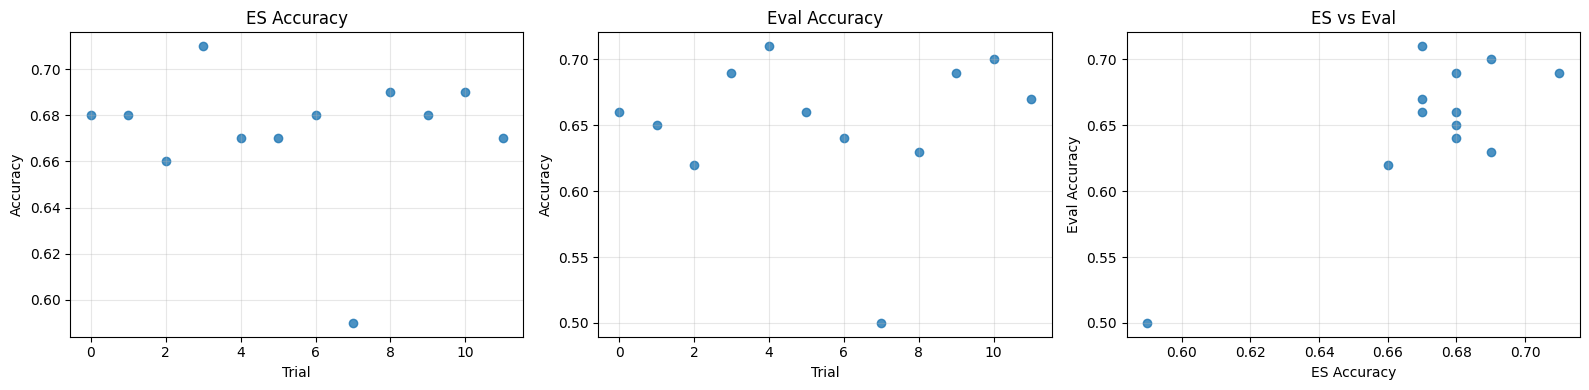

In [7]:
print(results_df.head(10)[[
    'trial', 'vocab_size', 'embedding_dim', 'n_filters', 'filter_sizes',
    'dropout', 'lr', 'batch_size', 'epochs', 'es_acc', 'eval_acc', 'selection_score'
]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(results_df['trial'], results_df['es_acc'], alpha=0.8)
axes[0].set_title('ES Accuracy')
axes[1].scatter(results_df['trial'], results_df['eval_acc'], alpha=0.8)
axes[1].set_title('Eval Accuracy')
axes[2].scatter(results_df['es_acc'], results_df['eval_acc'], alpha=0.8)
axes[2].set_title('ES vs Eval')

for ax in axes:
    ax.set_xlabel('Trial')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Accuracy')
axes[1].set_ylabel('Accuracy')
axes[2].set_xlabel('ES Accuracy')
axes[2].set_ylabel('Eval Accuracy')

plt.tight_layout()
plt.show()


## 6. Avaliação do Melhor Modelo


{'vocab_size': 1000, 'embedding_dim': 100, 'n_filters': 64, 'filter_sizes': (2, 3, 4), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32, 'max_len': 200, 'epochs': 30, 'patience': 8}
Selection score: 0.7000

=== Melhor CNN1D - ES (subm1) ===
Accuracy: 0.7100 | Macro F1: 0.6459
              precision    recall  f1-score   support

   Anthropic       0.52      0.82      0.64        17
      Google       0.80      0.24      0.36        17
       Human       0.73      0.97      0.84        34
        Meta       0.93      0.78      0.85        18
      OpenAI       0.75      0.43      0.55        14

    accuracy                           0.71       100
   macro avg       0.75      0.65      0.65       100
weighted avg       0.75      0.71      0.68       100



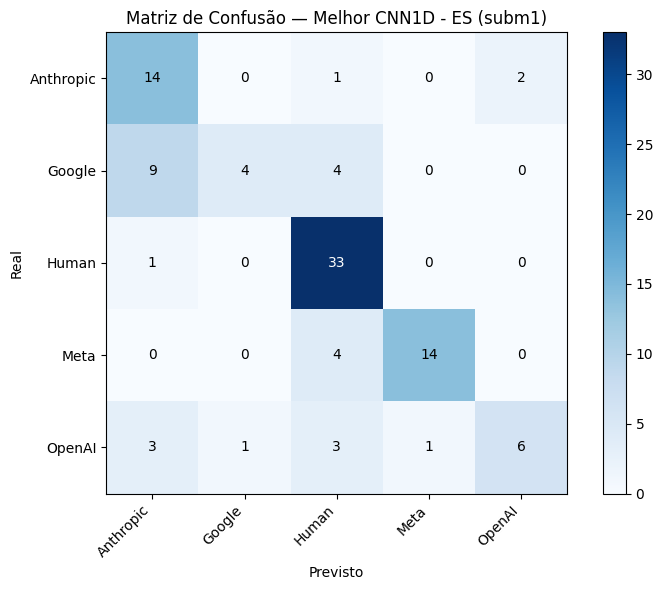


=== Melhor CNN1D - Eval (subm2) ===
Accuracy: 0.6900 | Macro F1: 0.6713
              precision    recall  f1-score   support

   Anthropic       0.40      0.62      0.49        16
      Google       0.67      0.67      0.67        18
       Human       0.82      0.79      0.81        34
        Meta       0.81      0.81      0.81        16
      OpenAI       0.88      0.44      0.58        16

    accuracy                           0.69       100
   macro avg       0.71      0.67      0.67       100
weighted avg       0.73      0.69      0.70       100



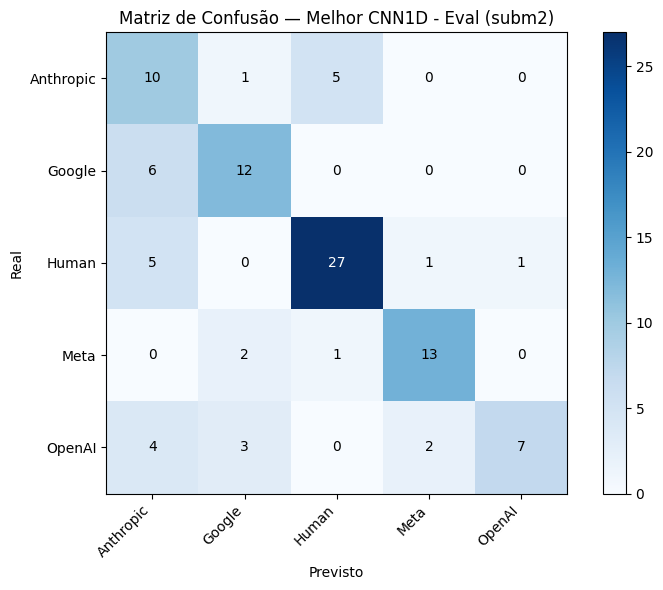

In [8]:
best_params = best_payload['params']
best_model = best_payload['model']
best_vocab = best_payload['vocab']
best_style_extractor = best_payload['style_extractor']
best_style_mean = best_payload['style_mean']
best_style_std = best_payload['style_std']

print(best_params)
print(f'Selection score: {best_selection_score:.4f}')

es_acc, es_f1, _ = evaluate_probs(best_payload['probs_es'], y_es, 'Melhor CNN1D - ES (subm1)')
eval_acc, eval_f1, _ = evaluate_probs(best_payload['probs_eval'], y_eval, 'Melhor CNN1D - Eval (subm2)')


## 7. Guardar Pesos


In [9]:
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
model_path = os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_model.pt')
vocab_path = os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_vocab.pkl')
style_stats_path = os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_style_stats.npz')
style_extractor_path = os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_style_extractor.pkl')

torch.save(best_model.state_dict(), model_path)
best_vocab.save(vocab_path)
np.savez(style_stats_path, mean=best_style_mean, std=best_style_std)
with open(style_extractor_path, 'wb') as f:
    pickle.dump(best_style_extractor, f)

print(f'Modelo guardado em {model_path}')
print(f'Vocabulário guardado em {vocab_path}')
print(f'Estatísticas guardadas em {style_stats_path}')
print(f'Extractor guardado em {style_extractor_path}')

with open(os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_config.json'), 'w') as f:
    json.dump(best_params, f)


Modelo guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/cnn1d_final_model.pt
Vocabulário guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/cnn1d_final_vocab.pkl
Estatísticas guardadas em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/cnn1d_final_style_stats.npz
Extractor guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/cnn1d_final_style_extractor.pkl


## 8. AUC-ROC

In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def compute_macro_auc(probs, labels):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    return np.mean(aucs)

cnn_auc_val1 = compute_macro_auc(best_payload['probs_es'], y_es)
cnn_auc_val2 = compute_macro_auc(best_payload['probs_eval'], y_eval)

print(f'CNN1D — Val1 Macro AUC: {cnn_auc_val1:.4f}')
print(f'CNN1D — Val2 Macro AUC: {cnn_auc_val2:.4f}')

CNN1D — Val1 Macro AUC: 0.8744
CNN1D — Val2 Macro AUC: 0.9082


## 9. Comparação CNN1D vs. BiLSTM

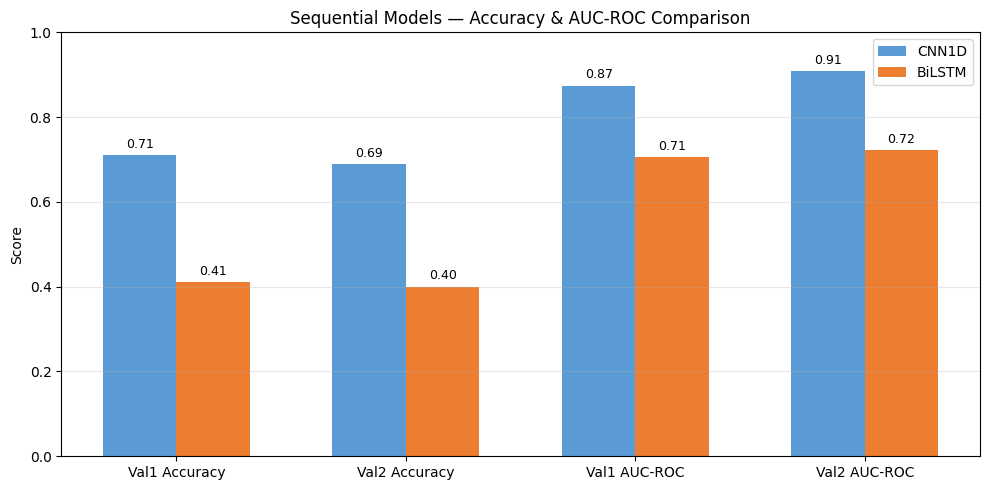

In [11]:
lstm_val1_acc = 0.41
lstm_val2_acc = 0.40
lstm_val1_auc = 0.7063
lstm_val2_auc = 0.7226

cnn_val1_acc = es_acc
cnn_val2_acc = eval_acc

metrics = ['Val1 Accuracy', 'Val2 Accuracy', 'Val1 AUC-ROC', 'Val2 AUC-ROC']
cnn_vals = [cnn_val1_acc, cnn_val2_acc, cnn_auc_val1, cnn_auc_val2]
lstm_vals = [lstm_val1_acc, lstm_val2_acc, lstm_val1_auc, lstm_val2_auc]

x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cnn_vals, width, label='CNN1D', color='#5B9BD5')
bars2 = ax.bar(x + width/2, lstm_vals, width, label='BiLSTM', color='#ED7D31')

ax.set_ylabel('Score')
ax.set_title('Sequential Models — Accuracy & AUC-ROC Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()